In [1]:
import os

os.environ.setdefault("XLA_FLAGS", "--xla_force_host_platform_device_count=12")
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")
print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]


In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
for parent in [repo_root, *repo_root.parents]:
    src = parent / "src"
    if (src / "gwemfish").is_dir():
        sys.path.insert(0, str(src))
        break

import matplotlib.pyplot as plt

from gwemfish.simple_pipeline import (
    _deep_merge_dict,
    make_default_cfg,
    plot_system_observation,
    setup_em_observation,
    setup_gw_observation,
    run_inference, 
    plot_posterior, 
    to_source_plane_samples, 
    plot_source_posterior,
)
#
#OUTPUT_DIR = os.path.join("examples", "outputs", "simple_pipeline_demonstration")
#os.makedirs(OUTPUT_DIR, exist_ok=True)
#print("OUTPUT_DIR:", os.path.abspath(OUTPUT_DIR))

In [3]:
from gwemfish.config import DEFAULT_KWARGS_NUMERICS, SOLVER_PARAMS
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
sample_cfg = {
    "em": {
        "pixel_grid_kwargs": {"npix": int(40), "pix_scl": 0.1},
        "psf_kwargs": {"psf_type": "GAUSSIAN", "fwhm": 0.16, "pixel_size": 0.1},#0.067
        "noise_simu_kwargs": {"npix": int(40), "background_rms": 5e-2, "exposure_time": 2200},
        "noise_inf_kwargs": {"npix": int(40), "background_rms": None, "exposure_time": 2200},
        "kwargs_numerics": DEFAULT_KWARGS_NUMERICS,
        "exposure_time": 2200,
        "seed": 87651,
        "source_pos": (0.0, 0.0), #Is this the position of the source of the GW or the position of the center of the source galaxy?
        "kwargs_source": [
            {
                "amp": 250,
                "R_sersic": 0.4,
                "n_sersic": 4.0,
                "e1": 0,
                "e2": 0,
                "center_x": 0.0, #same question for these center_x and y values
                "center_y": 0.0,
            }
        ],
        "kwargs_lens_light": [
            {
                "amp": 50.0,
                "R_sersic": 2.0,
                "n_sersic": 4.0,
                "e1": 0.0,
                "e2": 0.0,
                "center_x": 0.0,
                "center_y": 0.0,
            }
        ],
    },
    "lens": {
        "lens_model_list": ["EPL", "SHEAR"],
        "kwargs_lens": [
            {
                "theta_E": 1.2,
                "e1": 0.0,
                "e2": 0.1,
                "gamma": 2.0,
                "center_x": 0.0,
                "center_y": 0.0,
            },
            {"gamma1": 0.1, "gamma2": 0.0, "ra_0": 0.0, "dec_0": 0.0},
        ],
        "zl": 0.7,
        "zs": 1.5,
    },
    "gw": {
        "source_pos": (0.0, 0.0),
        "solver_params": SOLVER_PARAMS,
        "image_box_half_width": 10.6,
        "error_scales": {
            "sigma_td": 0.05,
            "sigma_dL_eff": 3.0,
            "epsilon": 0.005,
        },
    },
    "plot": {"plot_mode": "groupwise", "save_path": None, "save_tag": None, "hist_kwargs": {"density": True}},
    "source_plane": {"filter_std": None, "use_filtered": False},
    "output": {
        "output_dir": OUTPUT_DIR,
        "save_samples_path": None,
        "save_truths_path": None,
        "save_source_samples_path": None,
        "save_system_plot_path": None,
        "json_path": None,
    },
}

In [6]:
from lenstronomy.Util import param_util
from lenstronomy.SimulationAPI.mag_amp_conversion import MagAmpConversion

In [7]:
import copy

def row_to_cfg(row, sample_cfg, gw_enabled):
    """
    Convert one row of the Qiuhan's sky catalog into a GWEMFISH configuration.

    Parameters
    ----------
    row : pandas.Series
        One row of the lens catalog.

    sample_cfg : dict
        Reference GWEMFISH config.

    Returns
    -------
    cfg : dict
        GWEMFISH configuration for this lens system.
    """

    cfg = copy.deepcopy(sample_cfg)

    # ==========================================================
    # Convert axis ratio + PA -> ellipticity
    # ==========================================================

    # --- 1. PREPARE LENS (DEFLECTOR) LIGHT PARAMETERS ---
    # Convert q and pa to lenstronomy ellipticity (e1, e2)
    lens_e1, lens_e2 = param_util.phi_q2_ellipticity(phi=row['deflector_pa'], q=row['deflector_q'])


    kwargs_lens_light_mag = [{
    'magnitude': row['deflector_app_mag_VIS'],
    'R_sersic': row['deflector_Re'],
    'n_sersic': 4.0,  # Standard assumption for elliptical lens galaxies
    'e1': lens_e1, 'e2': lens_e2,
    'center_x': 0, 'center_y': 0
    }]

    # --- 2. PREPARE SOURCE LIGHT PARAMETERS ---
    # Convert q and pa to lenstronomy ellipticity (e1, e2)
    source_e1, source_e2 = param_util.phi_q2_ellipticity(phi=row['source_pa'], q=row['source_q'])
    
    # Choose your band (e.g., VIS)
    kwargs_source_mag = [{
        'magnitude': row['source_app_mag_VIS'], 
        'R_sersic': row['source_Re'],
        'n_sersic': row['source_sersic_index'],
        'e1': source_e1, 'e2': source_e2,
        'center_x': row['source_relative_x'], 
        'center_y': row['source_relative_y']
    }]
    
    # --- 3. CONVERT BOTH TO AMP ---
    # Define your model profile types
    kwargs_model = {
        'lens_light_model_list': ['SERSIC_ELLIPSE'],
        'source_light_model_list': ['SERSIC_ELLIPSE']
    }
    
    # Initialize the converter with your survey zero-point
    mag_converter = MagAmpConversion(kwargs_model=kwargs_model, magnitude_zero_point=25.9)
    
    # Get the final dictionaries containing the calculated 'amp' keys
    lens_light_amp = mag_converter.magnitude2amplitude(kwargs_lens_light_mag=kwargs_lens_light_mag)
    source_amp = mag_converter.magnitude2amplitude(kwargs_source_mag=kwargs_source_mag)
    
    #print(lens_light_amp)
    #print(source_amp)
    
    #source_e1, source_e2 = q_pa_to_e1e2(
     #   row["source_q"],
      #  row["source_pa"],
   # )

    lens_pos = (float(row['deflector_ra']), float(row['deflector_dec']))
    
    source_pos = (float(row["source_relative_x"]), float(row["source_relative_y"]))

    # ==========================================================
    # Lens geometry
    # ==========================================================

    cfg["lens"]["zl"] = float(row["deflector_z"])
    cfg["lens"]["zs"] = float(row["source_z"])

    # ==========================================================
    # Lens mass model (EPL)
    # ==========================================================

    cfg["lens"]["kwargs_lens"][0]["theta_E"] = float(row["deflector_thetaE"])
    cfg["lens"]["kwargs_lens"][0]["gamma"] = float(row["deflector_slope"])

    cfg["lens"]["kwargs_lens"][0]["e1"] = float(lens_e1)
    cfg["lens"]["kwargs_lens"][0]["e2"] = float(lens_e2)

    cfg["lens"]["kwargs_lens"][0]["center_x"] = 0.00
    cfg["lens"]["kwargs_lens"][0]["center_y"] = 0.00

    # ==========================================================
    # External shear
    # ==========================================================

    cfg["lens"]["kwargs_lens"][1]["gamma1"] = float(row["deflector_shear1"])
    cfg["lens"]["kwargs_lens"][1]["gamma2"] = float(row["deflector_shear2"])

    cfg["lens"]["kwargs_lens"][1]["ra_0"] = 0.00
    cfg["lens"]["kwargs_lens"][1]["dec_0"] = 0.00

    # ==========================================================
    # Source light
    # ==========================================================

    cfg["em"]["kwargs_source"][0]["R_sersic"] = float(row["source_Re"])
    cfg["em"]["kwargs_source"][0]["n_sersic"] = float(row["source_sersic_index"])

    cfg["em"]["kwargs_source"][0]["e1"] = float(source_e1)
    cfg["em"]["kwargs_source"][0]["e2"] = float(source_e2)

    cfg["em"]["kwargs_source"][0]["center_x"] = source_pos[0]
    cfg["em"]["kwargs_source"][0]["center_y"] = source_pos[1]

    cfg["em"]["kwargs_source"][0]["amp"] = float(source_amp[1][0]['amp'])

    # ==========================================================
    # Lens light
    # ==========================================================

    cfg["em"]["kwargs_lens_light"][0]["R_sersic"] = float(row["deflector_Re"])
    cfg["em"]["kwargs_lens_light"][0]["n_sersic"] = float(4)

    cfg["em"]["kwargs_lens_light"][0]["e1"] = float(lens_e1)
    cfg["em"]["kwargs_lens_light"][0]["e2"] = float(lens_e2)

    cfg["em"]["kwargs_lens_light"][0]["center_x"] = 0.00
    cfg["em"]["kwargs_lens_light"][0]["center_y"] = 0.00

    cfg["em"]["kwargs_lens_light"][0]["amp"] = float(lens_light_amp[0][0]['amp'])

    # ==========================================================
    # GW source position
    # ==========================================================
    cfg["em"]["source_pos"] = source_pos
    
    if gw_enabled is True:
        cfg["gw"]["source_pos"] = (source_pos[0]+0.005, source_pos[1]-0.005)

    if gw_enabled is False:
        cfg["gw"] = {"enabled": False}

    return cfg

## Prepare to implement data from Qiuhan's catalog

In [8]:
import pandas as pd

In [9]:
df = pd.read_csv('../data_catalog/Qiuhan/Euclid_cats/filtered_lens_catalog_PL_IC_gt_70.csv')

In [10]:
df.columns

Index(['deflector_ra', 'deflector_dec', 'deflector_z', 'deflector_q',
       'deflector_pa', 'deflector_vdisp', 'deflector_rband_abs_mag',
       'deflector_Re', 'deflector_thetaE', 'deflector_thetaE_autolens',
       'deflector_slope', 'deflector_einstein_mass', 'deflector_shear1',
       'deflector_shear2', 'source_z', 'source_max_image_multiplicity',
       'source_ra', 'source_dec', 'source_relative_x', 'source_relative_y',
       'source_pa', 'source_q', 'source_Re', 'source_sersic_index',
       'source_mStar', 'source_SFR_100', 'source_metallicity',
       'deflector_app_mag_VIS', 'source_app_mag_VIS', 'source_app_mag_F106',
       'source_app_mag_F129', 'source_app_mag_F158', 'source_app_mag_g',
       'source_app_mag_r', 'source_app_mag_i', 'source_app_mag_z', 'IC_Euclid',
       'IC_CSST', 'IC_Roman', 'IC_nofactor_Euclid', 'IC_nofactor_CSST',
       'IC_nofactor_Roman', 'origin_batch'],
      dtype='str')

Below is a list of targets with ID below 1000 that has failed in EM-only parameter estimation
- 406
- 419
- 425
- 463
- 491
- 510
- 536
- 552
- 553
- 565 
- 570 
- 585
- 604
- 609
- 623
- 634
- 641
- 658
- 673
- 686
- 787
- 790
- 805
- 807
- 811
- 817
- 818
- 917
- 920
- 957 
- 970
- 985

In [11]:
source_galaxy = df.iloc[565:566]

In [20]:
row = source_galaxy.iloc[0]
cfg_gw_source = row_to_cfg(row, sample_cfg, True)
cfg_gw_source["use_parameter_layout"] = True

In [21]:
cfg_gw_source['em']

{'pixel_grid_kwargs': {'npix': 40, 'pix_scl': 0.1},
 'psf_kwargs': {'psf_type': 'GAUSSIAN', 'fwhm': 0.16, 'pixel_size': 0.1},
 'noise_simu_kwargs': {'npix': 40,
  'background_rms': 0.05,
  'exposure_time': 2200},
 'noise_inf_kwargs': {'npix': 40,
  'background_rms': None,
  'exposure_time': 2200},
 'kwargs_numerics': {'supersampling_factor': 1},
 'exposure_time': 2200,
 'seed': 87651,
 'source_pos': (0.0249363166567651, 0.130280762122803),
 'kwargs_source': [{'amp': 4.744291192478658,
   'R_sersic': 0.2265042280466752,
   'n_sersic': 0.5847619357201114,
   'e1': -0.12087911805113767,
   'e2': -0.33216777630749317,
   'center_x': 0.0249363166567651,
   'center_y': 0.130280762122803}],
 'kwargs_lens_light': [{'amp': 8.935659218941762,
   'R_sersic': 0.6837447828142299,
   'n_sersic': 4.0,
   'e1': 0.1353984783750205,
   'e2': 0.03644619607475291,
   'center_x': 0.0,
   'center_y': 0.0}]}

In [22]:
#Make compatible with Euclid
cfg_gw_source['em']['pixel_grid_kwargs']['npix'] = 60
cfg_gw_source['em']['noise_simu_kwargs']['npix'] = 60
cfg_gw_source['em']['noise_inf_kwargs']['npix'] = 60
cfg_gw_source['em']['psf_kwargs']['fwhm'] = 0.16

cfg_gw_source['em']['kwargs_source'][0]['amp'] = 200

cfg_gw_source['em']['kwargs_lens_light'][0]['amp'] = 0

In [23]:
ctx_gw_source = setup_em_observation(cfg=cfg_gw_source)

In [24]:
ctx_gw_source = setup_gw_observation(ctx_gw_source, cfg=cfg_gw_source)

In [25]:
tp = ctx_gw_source['truth_params']

In [26]:
tp

{'source_amp': 4.744291192478658,
 'source_R_sersic': 0.2265042280466752,
 'source_n': 0.5847619357201114,
 'source_e1': -0.12087911805113767,
 'source_e2': -0.33216777630749317,
 'source_center_x': 0.0249363166567651,
 'source_center_y': 0.130280762122803,
 'light_amp': 8.935659218941762,
 'light_R_sersic': 0.6837447828142299,
 'light_n': 4.0,
 'light_e1': 0.1353984783750205,
 'light_e2': 0.03644619607475291,
 'light_center_x': 0.0,
 'light_center_y': 0.0,
 'noise_sigma_bkg': 0.05,
 'x_image_true_em': Array([ 0.4234601 , -0.35793377, -0.84017989,  0.6132584 ], dtype=float64),
 'y_image_true_em': Array([ 1.3229783 , -0.95912913, -0.15799289, -0.49901764], dtype=float64),
 'lens0_gamma': 1.8023603295249293,
 'lens0_theta_E': 1.00077056164227,
 'lens0_e1': 0.1353984783750205,
 'lens0_e2': 0.03644619607475291,
 'lens0_center_x': 0.0,
 'lens0_center_y': 0.0,
 'lens1_gamma1': -0.0478187637595228,
 'lens1_gamma2': 0.1213914523854247,
 'lens1_ra_0': 0.0,
 'lens1_dec_0': 0.0,
 'source0_amp': 4

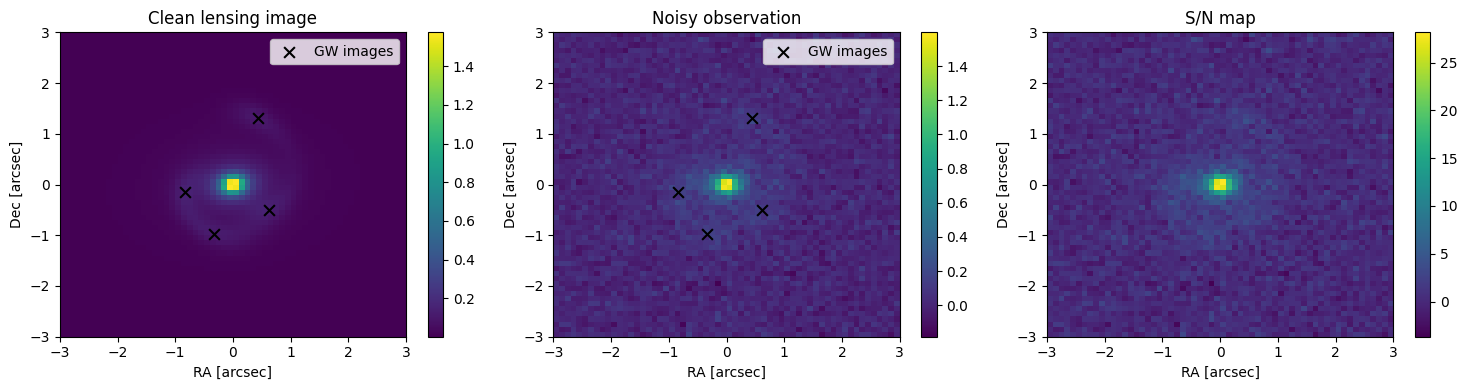

In [27]:
fig = plot_system_observation(
    ctx_gw_source,
    cfg={"output": {"save_system_plot_path": None}} #os.path.join(OUTPUT_DIR, "system_observation.png")}},
)
plt.show()

from gwemfish import simulate_in_pal, plot_system_observation_pal, save_pal_outputs
OUT = "examples/outputs/pal_mirror"
ctx_pal = simulate_in_pal(ctx_gw_source)
plot_system_observation_pal(ctx_pal, cfg={"output": {"output_dir": OUT, "save_pal_dataset_plot_path": "dataset_subplot.png", "save_pal_tracer_plot_path": "tracer.png"}, "plot": {"pal_dataset": "both"}})
save_pal_outputs(ctx_pal, OUT, dataset="both")

In [22]:
list_of_lens_mass = []
for i in range(len(df)):
    row = df.iloc[i]
    lens_e1, lens_e2 = param_util.phi_q2_ellipticity(phi=row['deflector_pa'], q=row['deflector_q'])
    thetaE = float(row["deflector_thetaE"])
    gamma = float(row["deflector_slope"])
    gamma1 = float(row["deflector_shear1"])
    gamma2 = float(row["deflector_shear2"])
    pair = (i, lens_e1, lens_e2, thetaE, gamma, gamma1, gamma2)
    list_of_lens_mass.append(pair)

In [24]:
e1_all = [item[1] for item in list_of_lens_mass]
e2 = [item[2] for item in list_of_lens_mass]
thetas = [item[3] for item in list_of_lens_mass]
gammas = [item[4] for item in list_of_lens_mass]
gamma1s = [item[5] for item in list_of_lens_mass]
gamma2s = [item[6] for item in list_of_lens_mass]

In [26]:
population = {'lens0_e1': e1_all, 'lens0_e2': e2, 'lens0_gamma': gammas, 'lens0_theta_E': thetas, 'lens1_gamma1': gamma1s, 'lens1_gamma2': gamma2s}

In [27]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

kde_e1 = gaussian_kde(e1_all)
kde_e2 = gaussian_kde(e2)
kde_thetaE = gaussian_kde(thetas)
kde_gamma = gaussian_kde(gammas)
kde_gamma1 = gaussian_kde(gamma1s)
kde_gamma2 = gaussian_kde(gamma2s)

In [28]:
# A version of KDEPrior class that truncates the KDE
import numpy as np
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from scipy.stats import gaussian_kde

class KDEPrior:
    def __init__(self, name, data, low=None, high=None):
        self.name = name

        # Build scipy KDE to determine the bandwidth
        kde = gaussian_kde(data)

        self.data = jnp.asarray(data)

        # 1D KDE bandwidth
        self.bandwidth = float(
            np.sqrt(kde.covariance[0, 0])
        )

        n = len(data)

        # Truncated Gaussian components
        component_dist = dist.TruncatedNormal(
            loc=self.data,
            scale=self.bandwidth,
            low=low,
            high=high
        )

        # Equivalent truncated Gaussian mixture
        self.distribution = dist.MixtureSameFamily(
            dist.Categorical(
                probs=jnp.ones(n) / n
            ),
            component_dist
        )

    def __call__(self):
        return numpyro.sample(
            self.name,
            self.distribution
        )

## Setup priors for parameter estimations

In [28]:
import numpyro.distributions as dist

In [29]:
import copy

ctx_gw_source_em = copy.deepcopy(ctx_gw_source)
ctx_gw_source_gw = copy.deepcopy(ctx_gw_source)
ctx_gw_source_both = copy.deepcopy(ctx_gw_source)

In [30]:
tp['lens0_e1']

0.1353984783750205

In [31]:
tp['lens0_theta_E']

1.00077056164227

### Using Otto's old priors

"The GW image positions are unknown, but we assume that we already know the lens model parameters to comparable precision to a rough initial lens model obtainable from ground-based imaging of the lensed EM host (Kostrzewa-Rutkowska et al. 2014)."

"Specifically, we assume (0.01, 0.05, 0.03) spread (one-standard-deviation) on the measurement of the Einstein radius, axis-ratio, and each shear component, respectively. We assume the power-law density profile of the lens to be unconstrained by the existing data, adopting instead a prior typical of the strong lens population: a mean slope γ = 2 with 0.2 spread."

In [32]:
row['deflector_q']

np.float64(0.7540506200364769)

In [33]:
phi = row['deflector_pa']

In [34]:
sigma_e = 2/((1+row['deflector_q'])**2) * 0.05
sigma_e1 = abs(np.cos(2*phi)) * sigma_e
sigma_e2 = abs(np.sin(2*phi)) * sigma_e

In [35]:
print(sigma_e1, sigma_e2)

0.03138527433997796 0.008448203230811047


In [36]:
ctx_gw_source_em["cfg"]["priors"] = {
        #"T_star": float(tp["T_star"]),
        #"dL": float(tp["dL"]),
        'lens0_gamma': dist.Normal(2.0, 0.2),
          'lens0_theta_E': dist.Normal(tp['lens0_theta_E'], 0.1),
         'source0_n_sersic': dist.Uniform(0.8, 5.0),
         #"source0_R_sersic": dist.Uniform()
         #'lens0_e1': float(tp["lens0_e1"]), 
         #'lens0_e2': float(tp['lens0_e2']),
         'lens0_e1': dist.Normal(0, sigma_e1),
         'lens0_e2': dist.Normal(0, sigma_e2),
         'lens0_center_x': 0.0, #dist.Normal(0, lens_prior_sigma['lens0_center_x']),
         'lens0_center_y': 0.0, #dist.Normal(0, lens_prior_sigma['lens0_center_y']),
         #'lens1_gamma1': float(tp["lens1_gamma1"]),
         #'lens1_gamma2': float(tp["lens1_gamma2"]),
         'lens1_gamma1': dist.Normal(0, 0.01),
         'lens1_gamma2': dist.Normal(0, 0.01),
         'lens1_ra_0': 0.0,
         'lens1_dec_0': 0.0,
          #'light0_R_sersic': float(tp["light0_R_sersic"]),
          #'light0_n_sersic': float(tp["light0_n_sersic"]),
          'light0_amp': float(tp['light0_amp']),
         #'light0_e1': float(tp["light0_e1"]),
         #'light0_e2': float(tp["light0_e2"]),
         'light0_center_x': float(tp["light0_center_x"]),
         'light0_center_y': float(tp["light0_center_y"]),
          #"noise_sigma_bkg": tp["noise_sigma_bkg"],  
        } 

In [37]:
ctx_gw_source_gw["cfg"]["priors"] = {
        "T_star": float(tp["T_star"]),
        "dL": float(tp["dL"]),
        'lens0_gamma': dist.TruncatedNormal(2.0, 0.1, low=0.001, high=5.0),
          'lens0_theta_E': dist.TruncatedNormal(tp['lens0_theta_E'], 0.01, low=0.001, high=5.0),
         #'lens0_e1': float(tp["lens0_e1"]), 
         #'lens0_e2': float(tp['lens0_e2']),
         'lens0_e1': dist.Normal(tp['lens0_e1'], sigma_e1),
         'lens0_e2': dist.Normal(tp['lens0_e2'], sigma_e2),
         'lens0_center_x': 0.0, #dist.Normal(0, lens_prior_sigma['lens0_center_x']),
         'lens0_center_y': 0.0, #dist.Normal(0, lens_prior_sigma['lens0_center_y']),
         #'lens1_gamma1': float(tp["lens1_gamma1"]),
         #'lens1_gamma2': float(tp["lens1_gamma2"]),
         'lens1_gamma1': dist.Normal(tp['lens1_gamma1'], 0.03),
         'lens1_gamma2': dist.Normal(tp['lens1_gamma2'], 0.03),
         'lens1_ra_0': 0.0,
         'lens1_dec_0': 0.0,
          'light0_R_sersic': float(tp["light0_R_sersic"]),
          'light0_n_sersic': float(tp["light0_n_sersic"]),
          'light0_amp': float(tp['light0_amp']),
         'light0_e1': float(tp["light0_e1"]),
         'light0_e2': float(tp["light0_e2"]),
         'light0_center_x': float(tp["light0_center_x"]),
         'light0_center_y': float(tp["light0_center_y"]),
          "noise_sigma_bkg": tp["noise_sigma_bkg"],  
        } 

## Perform GW-only parameter estimation

In [38]:
method = 'deriv-approx'
samples_gw_source_GW, truths_gw_source_GW = run_inference(
    ctx_gw_source_gw,
    mode= "GW-only", #"EM+GW",#"EM-only",#"GW-only",
    method=method,
    cfg={
        "output": {"json_tag": method},
        **({"inference": {"informed": True, "regularize": False,"num_chains": 8, "num_samples": 14500, "num_warmup": 9500}} if method == "deriv-approx" else {}),
        # "inference": {"num_chains": 12, "num_samples": 8000, "num_warmup": 8000, "n_fisher_samples": 10000},
    },
)

use_mst in probmodel: False
k_mst in keys_to_include: False
k_mst truth: None
keys_to_include: ['lens0_gamma', 'lens0_theta_E', 'lens0_e1', 'lens0_e2', 'lens1_gamma1', 'lens1_gamma2', 'image_x1', 'image_y1', 'image_x2', 'image_y2', 'image_x3', 'image_y3', 'image_x4', 'image_y4']
input_params: {'lens0_gamma': 1.8023603295249293, 'lens0_theta_E': 1.00077056164227, 'lens0_e1': 0.1353984783750205, 'lens0_e2': 0.03644619607475291, 'lens1_gamma1': -0.0478187637595228, 'lens1_gamma2': 0.1213914523854247, 'image_x1': 0.43642628140425016, 'image_y1': 1.3153741019325043, 'image_x2': -0.3324364549205975, 'image_y2': -0.9708697098946127, 'image_x3': -0.8353344755448245, 'image_y3': -0.14188760928969754, 'image_x4': 0.6215331246721642, 'image_y4': -0.501042609551287}
Done with gradient
Done with Hessian
Scaled gradient at truth (g0 / sqrt|diag H0|):
  lens0_gamma               1.1444e-01
  lens0_theta_E             1.4228e-03
  lens0_e1                  3.7052e-03
  lens0_e2                 -1.2657

/Users/sangchunyeh/workspace/research/internship/2026_CUHK/lens_reconstruction/src/gwemfish/simple_pipeline.py:2105: UserWarning: Pre-inference diagnostics failed for method='deriv-approx', mode='GW-only'. See the [diag] lines above. Set cfg['inference']['diagnostics'] = 'warn' to continue anyway, or 'off' to skip these checks.
  diagnostics_report = diagnose_system(


Hessian-informed MCMC:
  u0:            [ 1.80236033  1.00077056  0.13539848  0.0364462  -0.04781876  0.12139145
  0.43642628  1.3153741  -0.33243645 -0.97086971 -0.83533448 -0.14188761
  0.62153312 -0.50104261]
  Param sigmas:  [0.09346489 0.00995371 0.02731722 0.00842465 0.02200667 0.02728917
 0.13720028 0.05655244 0.10364179 0.02848997 0.02954139 0.07224809
 0.05917895 0.07086607]
  Scale:         1.0
  Perturb scale: 0.1
cov shape: (14, 14)


  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

...

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]



[image_x1]      	 max r_hat: 1.0000


[image_x2]      	 max r_hat: 1.0000


[image_x3]      	 max r_hat: 1.0000


[image_x4]      	 max r_hat: 1.0000


[image_y1]      	 max r_hat: 1.0000


[image_y2]      	 max r_hat: 1.0000


[image_y3]      	 max r_hat: 1.0000


[image_y4]      	 max r_hat: 1.0000


[lens0_e1]      	 max r_hat: 1.0000


[lens0_e2]      	 max r_hat: 1.0000


[lens0_gamma]   	 max r_hat: 1.0000


[lens0_theta_E]  	 max r_hat: 1.0000


[lens1_gamma1]  	 max r_hat: 1.0000


[lens1_gamma2]  	 max r_hat: 1.0000


/Users/sangchunyeh/workspace/research/internship/2026_CUHK/lens_reconstruction/.venv/lib/python3.13/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


[<Figure size 1390x1390 with 36 Axes>, <Figure size 1810x1810 with 64 Axes>]

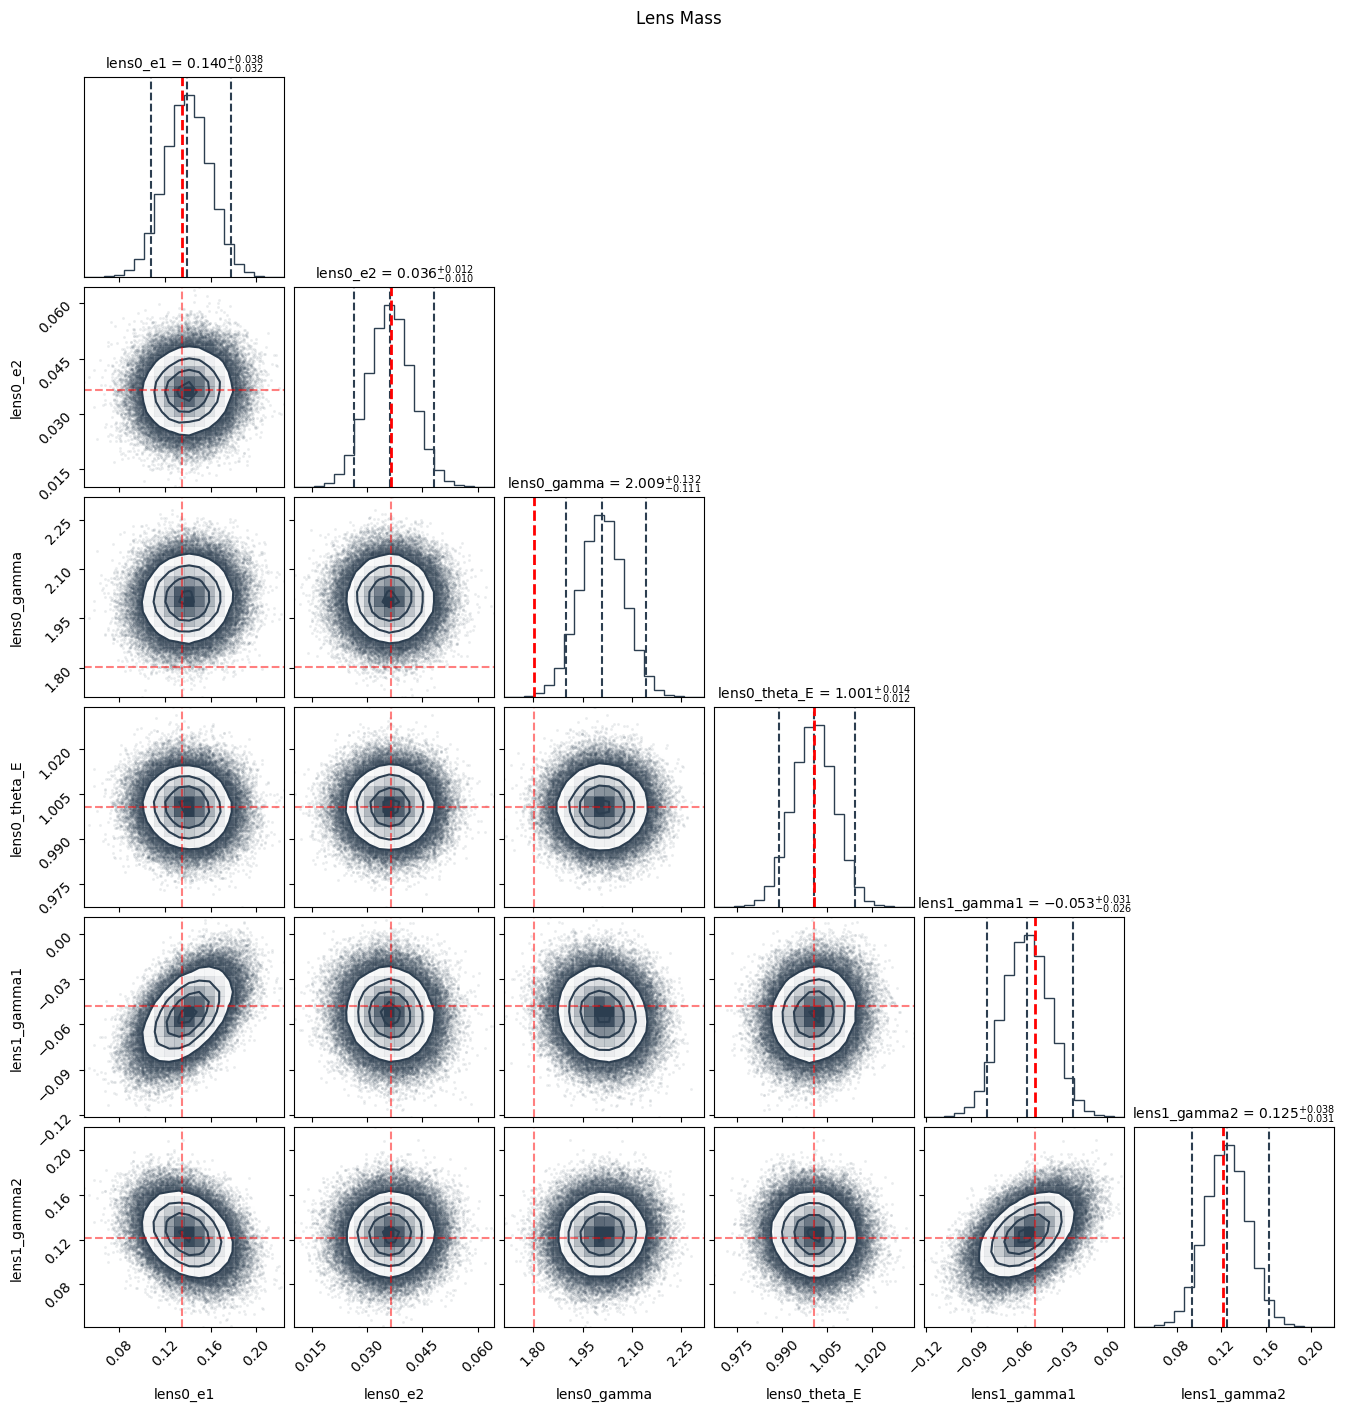

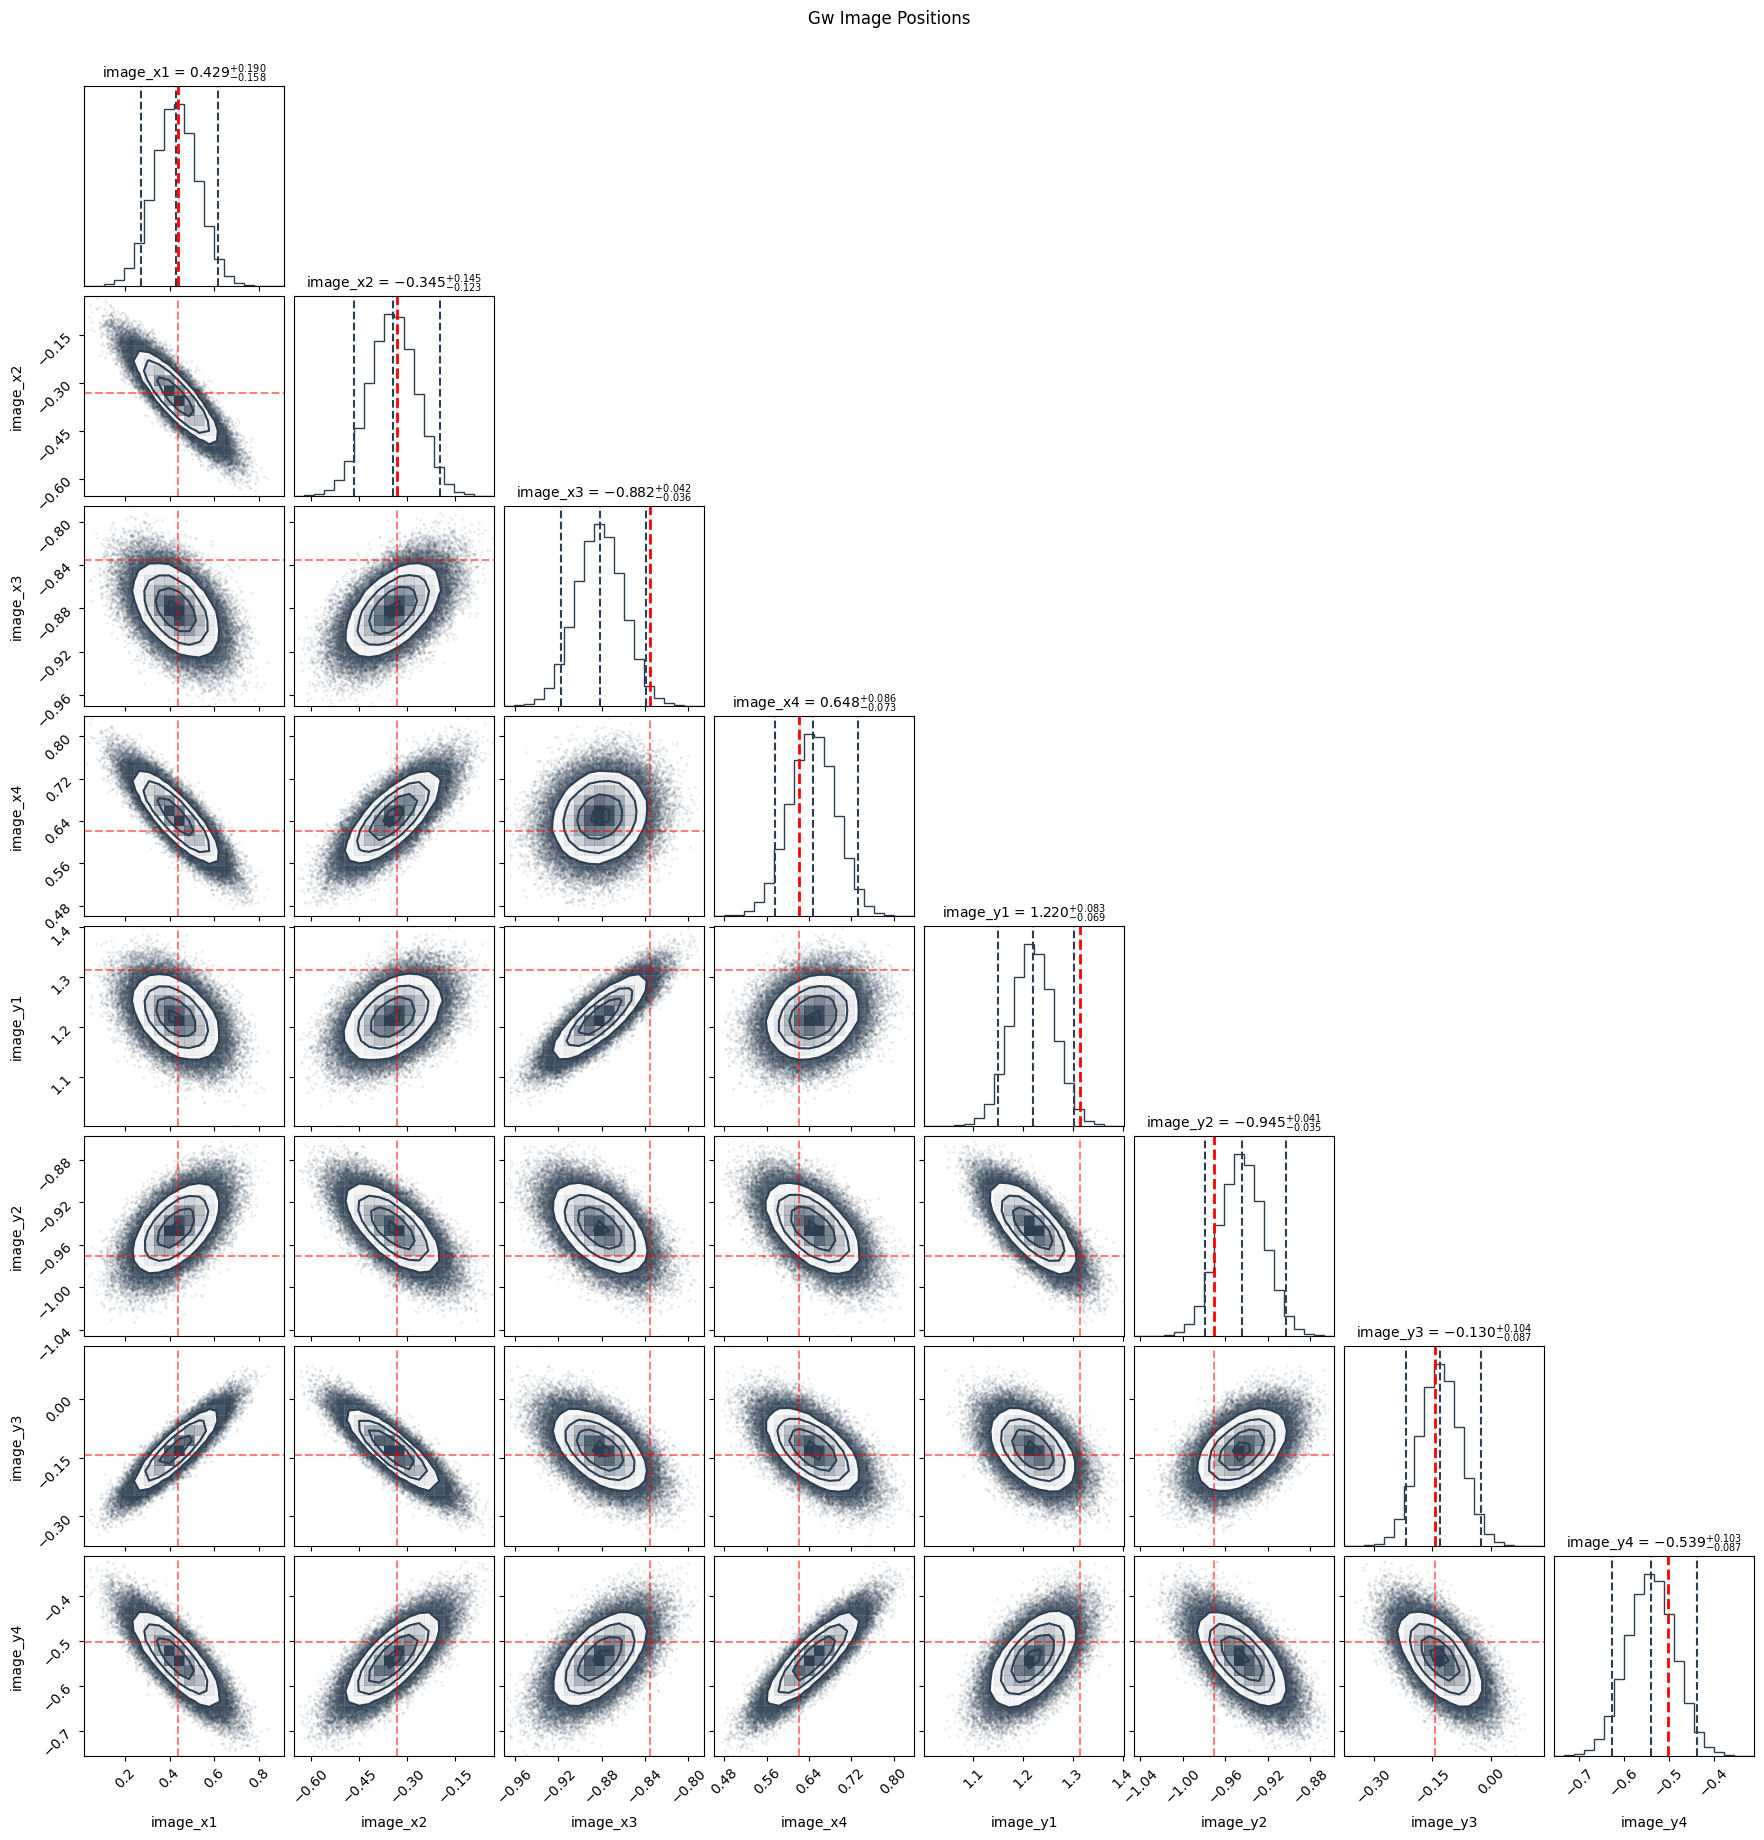

In [40]:
import corner

plot_posterior(
        samples_gw_source_GW,
        truths_gw_source_GW,
        cfg={
            "output": {"output_dir": None},
            "plot": {
               "plot_mode": "groupwise",
                "save_path": None,
            },
        },
    )

## Perform EM-only parameter estimation

In [41]:
method = 'deriv-approx'
samples_gw_source_EM, truths_gw_source_EM = run_inference(
    ctx_gw_source_em,
    mode= "EM-only", #"EM+GW",#"EM-only",#"GW-only",
    method=method,
    cfg={
        "output": {"json_tag": method},
        **({"inference": {"informed": True, "regularize": False,"num_chains": 8, "num_samples": 14500, "num_warmup": 9500}} if method == "deriv-approx" else {}),
        # "inference": {"num_chains": 12, "num_samples": 8000, "num_warmup": 8000, "n_fisher_samples": 10000},
    },
)

use_mst in probmodel: False
k_mst in keys_to_include: False
k_mst truth: None
keys_to_include: ['lens0_gamma', 'lens0_theta_E', 'lens0_e1', 'lens0_e2', 'lens1_gamma1', 'lens1_gamma2', 'source0_amp', 'source0_R_sersic', 'source0_n_sersic', 'source0_e1', 'source0_e2', 'source0_center_x', 'source0_center_y', 'light0_R_sersic', 'light0_n_sersic', 'light0_e1', 'light0_e2', 'noise_sigma_bkg']
input_params: {'lens0_gamma': 1.8023603295249293, 'lens0_theta_E': 1.00077056164227, 'lens0_e1': 0.1353984783750205, 'lens0_e2': 0.03644619607475291, 'lens1_gamma1': -0.0478187637595228, 'lens1_gamma2': 0.1213914523854247, 'source0_amp': 4.744291192478658, 'source0_R_sersic': 0.2265042280466752, 'source0_n_sersic': 0.5847619357201114, 'source0_e1': -0.12087911805113767, 'source0_e2': -0.33216777630749317, 'source0_center_x': 0.0249363166567651, 'source0_center_y': 0.130280762122803, 'light0_R_sersic': 0.6837447828142299, 'light0_n_sersic': 4.0, 'light0_e1': 0.1353984783750205, 'light0_e2': 0.03644619607

/Users/sangchunyeh/workspace/research/internship/2026_CUHK/lens_reconstruction/src/gwemfish/simple_pipeline.py:2105: UserWarning: Pre-inference diagnostics failed for method='deriv-approx', mode='EM-only'. See the [diag] lines above. Set cfg['inference']['diagnostics'] = 'warn' to continue anyway, or 'off' to skip these checks.
  diagnostics_report = diagnose_system(


Hessian-informed MCMC:
  u0:            [ 1.80236033  1.00077056  0.13539848  0.0364462  -0.04781876  0.12139145
  4.74429119  0.22650423  0.58476194 -0.12087912 -0.33216778  0.02493632
  0.13028076  0.68374478  4.          0.13539848  0.0364462   0.05      ]
  Param sigmas:  [1.04249948e-01 1.98669300e-02 2.96146867e-02 8.18904106e-03
 9.69617843e-03 8.63885881e-03 6.72746958e-01 2.83986514e-02
 1.59436781e-01 6.07008857e-02 5.76884264e-02 1.40677557e-02
 3.05945622e-02 1.77581065e-02 1.58545259e-01 1.88513165e-02
 1.62411001e-02 5.93026654e-04]
  Scale:         1.0
  Perturb scale: 0.1
cov shape: (18, 18)


  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

...

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]



[lens0_e1]      	 max r_hat: 1.0000


[lens0_e2]      	 max r_hat: 1.0000


[lens0_gamma]   	 max r_hat: 1.0000


[lens0_theta_E]  	 max r_hat: 1.0000


[lens1_gamma1]  	 max r_hat: 1.0000


[lens1_gamma2]  	 max r_hat: 1.0000


[light0_R_sersic]  	 max r_hat: 1.0000


[light0_e1]     	 max r_hat: nan


[light0_e2]     	 max r_hat: nan


[light0_n_sersic]  	 max r_hat: nan


[noise_sigma_bkg]  	 max r_hat: 1.0000


[source0_R_sersic]  	 max r_hat: 1.0000


[source0_amp]   	 max r_hat: nan


[source0_center_x]  	 max r_hat: nan


[source0_center_y]  	 max r_hat: nan


[source0_e1]    	 max r_hat: 1.0000


[source0_e2]    	 max r_hat: nan


[source0_n_sersic]  	 max r_hat: nan


In [42]:
samples_gw_source_EM

{'lens0_e1': Array([0.13539848, 0.13539848, 0.13539848, ..., 0.13539848, 0.13539848,
        0.13539848], dtype=float64),
 'lens0_e2': Array([0.0364462, 0.0364462, 0.0364462, ..., 0.0364462, 0.0364462,
        0.0364462], dtype=float64),
 'lens0_gamma': Array([1.80236033, 1.80236033, 1.80236033, ..., 1.80236033, 1.80236033,
        1.80236033], dtype=float64),
 'lens0_theta_E': Array([1.00077056, 1.00077056, 1.00077056, ..., 1.00077056, 1.00077056,
        1.00077056], dtype=float64),
 'lens1_gamma1': Array([-0.04781876, -0.04781876, -0.04781876, ..., -0.04781876,
        -0.04781876, -0.04781876], dtype=float64),
 'lens1_gamma2': Array([0.12139145, 0.12139145, 0.12139145, ..., 0.12139145, 0.12139145,
        0.12139145], dtype=float64),
 'light0_R_sersic': Array([0.68374478, 0.68374478, 0.68374478, ..., 0.68374478, 0.68374478,
        0.68374478], dtype=float64),
 'light0_e1': Array([0.13539848, 0.13539848, 0.13539848, ..., 0.13539848, 0.13539848,
        0.13539848], dtype=float64),


In [43]:
import jax.numpy as jnp
jnp.diag(jnp.linalg.inv(ctx_gw_source_em['fisher']['H0']))

Array([-1.08680517e-02, -3.94694908e-04, -8.77029670e-04, -6.70603935e-05,
       -9.40158762e-05, -7.46298816e-05, -4.52588469e-01, -8.06483404e-04,
       -2.54200872e-02, -3.68459752e-03, -3.32795454e-03, -1.97901749e-04,
       -9.36027236e-04, -3.15350347e-04, -2.51365990e-02, -3.55372133e-04,
       -2.63773334e-04, -3.51680612e-07], dtype=float64)

ValueError: It looks like the parameter(s) in column(s) 0, 1, 2, 3 have no dynamic range. Please provide a `range` argument.

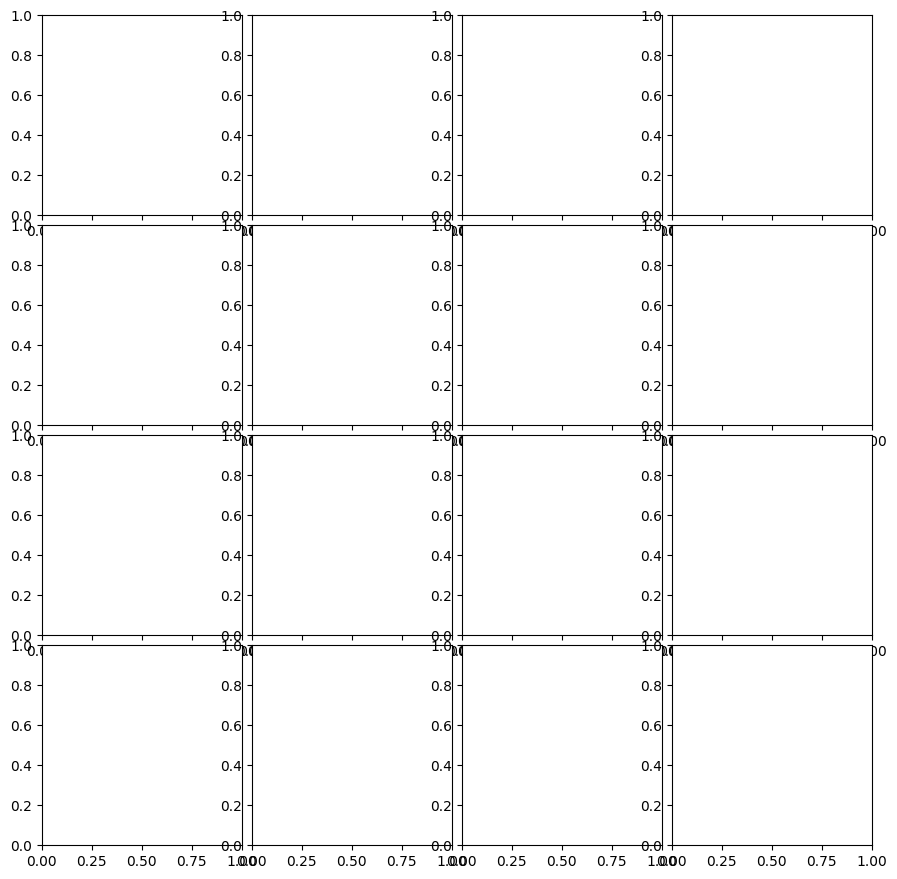

In [44]:
import corner

plot_posterior(
        samples_gw_source_EM,
        truths_gw_source_EM,
        cfg={
            "output": {"output_dir": None}, #'Otto_prior_trials'},
            "plot": {
                "plot_mode": "groupwise",
                "save_path": None, #'Tight_prior_deriv-approx.png',
            },
        },
    )

### Parameter estimation failed...!
